<a href="https://colab.research.google.com/github/sampabiet90/AIML/blob/LogicMojo-AI-ML-April26-sampa90/TalkingData_AdTracking_Fraud_Detection_Challenge.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
from google.colab import drive

In [5]:
drive.mount('/content/drive')

Mounted at /content/drive


In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [8]:
df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/train_sample.csv')

In [9]:
df.head()

,ip,app,device,os,channel,click_time,attributed_time,is_attributed
0,87540,12,1,13,497,2017-11-07 09:30:38,NaN,0
1,105560,25,1,17,259,2017-11-07 13:40:27,NaN,0
2,101424,12,1,19,212,2017-11-07 18:05:24,NaN,0
3,94584,13,1,13,477,2017-11-07 04:58:08,NaN,0
4,68413,12,1,1,178,2017-11-09 09:00:09,NaN,0


In [10]:
df.shape

(100000, 8)

In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 8 columns):
 #   Column           Non-Null Count   Dtype 
---  ------           --------------   ----- 
 0   ip               100000 non-null  int64 
 1   app              100000 non-null  int64 
 2   device           100000 non-null  int64 
 3   os               100000 non-null  int64 
 4   channel          100000 non-null  int64 
 5   click_time       100000 non-null  object
 6   attributed_time  227 non-null     object
 7   is_attributed    100000 non-null  int64 
dtypes: int64(6), object(2)
memory usage: 6.1+ MB


In [12]:
df.describe()

,ip,app,device,os,channel,is_attributed
count,100000.000000,100000.00000,100000.000000,100000.000000,100000.000000,100000.000000
mean,91255.879670,12.04788,21.771250,22.818280,268.832460,0.002270
std,69835.553661,14.94150,259.667767,55.943136,129.724248,0.047591
min,9.000000,1.00000,0.000000,0.000000,3.000000,0.000000
25%,40552.000000,3.00000,1.000000,13.000000,145.000000,0.000000
50%,79827.000000,12.00000,1.000000,18.000000,258.000000,0.000000
75%,118252.000000,15.00000,1.000000,19.000000,379.000000,0.000000
max,364757.000000,551.00000,3867.000000,866.000000,498.000000,1.000000


In [13]:
df.isnull().sum()

,0
ip,0
app,0
device,0
os,0
channel,0
click_time,0
attributed_time,99773
is_attributed,0


In [14]:
#attributed_time is not an important feature so we can drop it
df.drop(columns=['attributed_time'], inplace=True)

In [15]:
# count is_attributed to check the data imbalanced or not. Here data is highly imbalanced. plot it in the next step
df['is_attributed'].value_counts()

,count
is_attributed,
0,99773
1,227


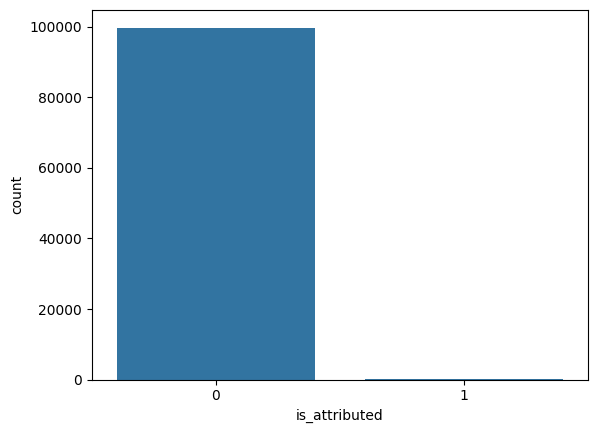

In [16]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x='is_attributed', data=df)
plt.show()

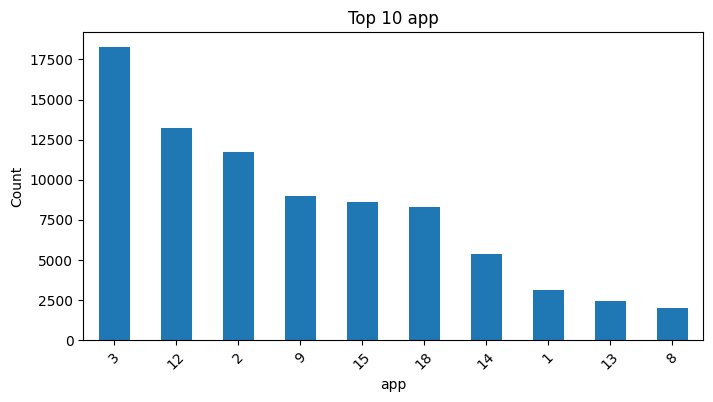

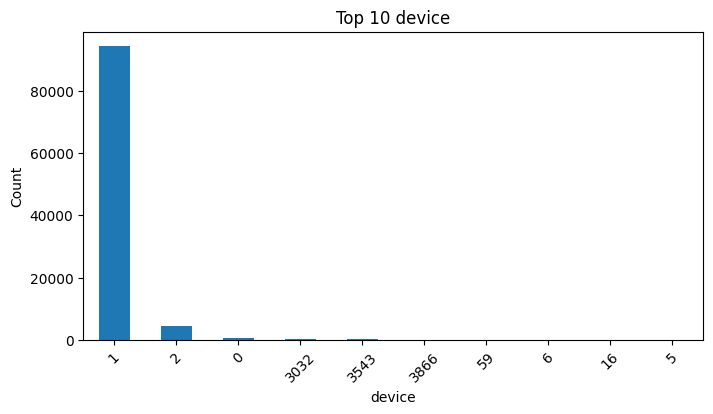

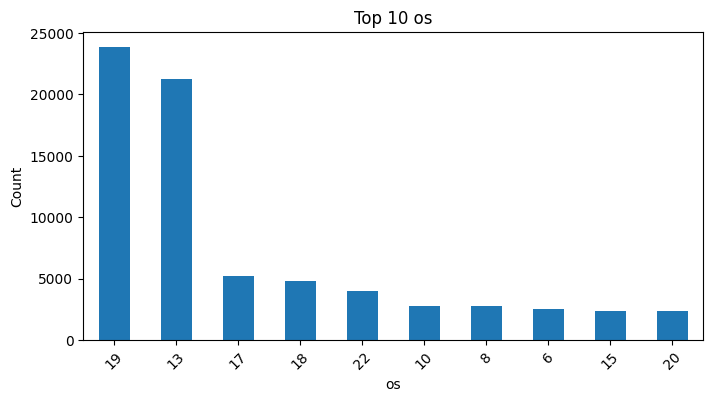

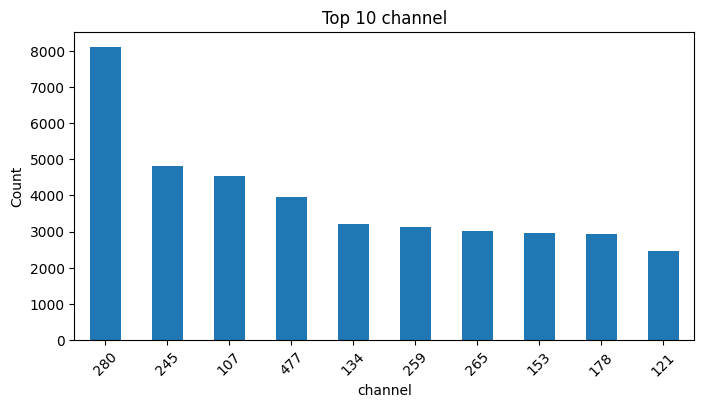

In [18]:
#Analyze each categorical values. show only top 10

categorical_cols = ['app', 'device', 'os', 'channel']

for col in categorical_cols:
    plt.figure(figsize=(8,4))
    df[col].value_counts().head(10).plot(kind='bar')
    plt.title(f'Top 10 {col}')
    plt.xlabel(col)
    plt.ylabel('Count')
    plt.xticks(rotation=45)
    plt.show()

In [ ]:
# FRom the above figures we can conclude that app id with 3 has most entry
# Device 1 has most entry
# OS 19 and 13 has most entry

In [28]:
#Bivariate Analysis . plot percentage for each attribute and observe the count. Data is highly imbalanced
cat_cols = ['app', 'device', 'os', 'channel']

for col in cat_cols:

 print(f"\n----- {col} -----")

 ct = pd.crosstab(
        df[col],
        df['is_attributed'],
        normalize='index'
    )

 print(ct.head())


----- app -----
is_attributed         0         1
app                              
1              1.000000  0.000000
2              1.000000  0.000000
3              0.999781  0.000219
4              1.000000  0.000000
5              0.925532  0.074468

----- device -----
is_attributed         0         1
device                           
0              0.903882  0.096118
1              0.998452  0.001548
2              0.999540  0.000460
4              0.666667  0.333333
5              1.000000  0.000000

----- os -----
is_attributed         0         1
os                               
0              0.869347  0.130653
1              0.999156  0.000844
2              0.997481  0.002519
3              0.999365  0.000635
4              0.990099  0.009901

----- channel -----
is_attributed         0         1
channel                          
3              0.995902  0.004098
4              1.000000  0.000000
5              0.285714  0.714286
13             1.000000  0.000000
15      

Feature Engineering

In [31]:
# We need to analyze , which time has the most installation

#Convert click time to date time
df['click_time'] = pd.to_datetime(df['click_time'])

df['hour'] = df['click_time'].dt.hour
df['day'] = df['click_time'].dt.day
df['weekday'] = df['click_time'].dt.dayofweek
df['day_of_year'] = df['click_time'].dt.dayofyear
df['month'] = df['click_time'].dt.month


df.groupby('hour')['is_attributed'].mean() # we can interprete from the result that 14 hour has highest install rate

,is_attributed
hour,
0,0.002299
1,0.002939
2,0.001947
3,0.002850
4,0.001656
5,0.002778
6,0.002363
7,0.002555
8,0.002841


In [32]:
df

,ip,app,device,os,channel,click_time,is_attributed,hour,day,weekday,day_of_year,month
0,87540,12,1,13,497,2017-11-07 09:30:38,0,9,7,1,311,11
1,105560,25,1,17,259,2017-11-07 13:40:27,0,13,7,1,311,11
2,101424,12,1,19,212,2017-11-07 18:05:24,0,18,7,1,311,11
3,94584,13,1,13,477,2017-11-07 04:58:08,0,4,7,1,311,11
4,68413,12,1,1,178,2017-11-09 09:00:09,0,9,9,3,313,11
...,...,...,...,...,...,...,...,...,...,...,...,...
99995,124883,11,1,19,122,2017-11-09 13:25:41,0,13,9,3,313,11
99996,85150,9,1,13,244,2017-11-07 11:25:43,0,11,7,1,311,11
99997,18839,3,1,13,19,2017-11-08 11:38:42,0,11,8,2,312,11
99998,114276,15,1,12,245,2017-11-08 17:55:21,0,17,8,2,312,11


In [33]:
# find install rate for week day . Those can be valid . Tuesday has the highest installation rate
install_rate = df.groupby('weekday')['is_attributed'].mean()
print(install_rate)

weekday
0    0.001596
1    0.002377
2    0.002439
3    0.002066
Name: is_attributed, dtype: float64


In [34]:
df.drop(columns=['click_time'], inplace=True)

In [ ]:
#Let's now build models to predict the variable is_attributed (downloaded).
#We'll try the several variants of boosting (adaboost, gradient boosting and XGBoost), tune the hyperparameters in each model and choose the one which gives the best performance.

In [35]:
# create x and y train
X = df.drop('is_attributed',axis=1)
y = df[['is_attributed']]

In [37]:
import sklearn
from sklearn.model_selection import train_test_split
from sklearn.model_selection import KFold
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import cross_val_score
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn import metrics

import xgboost as xgb
from xgboost import XGBClassifier
from xgboost import plot_importance
import gc # for deleting unused variables

In [38]:
# split data into train and test/validation sets
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.20,random_state=101)
print(X_train.shape)
print(y_train.shape)
print(X_test.shape)
print(y_test.shape)

(80000, 10)
(80000, 1)
(20000, 10)
(20000, 1)


In [40]:
# adaboost classifier with max 600 decision tress of depth=2
# learning_rate/shrinkage = 1.5

# base estimator
tree = DecisionTreeClassifier(max_depth=2)

# adaboost with the tree as base estimator
adaboost_model_1 = AdaBoostClassifier(estimator=tree,
                                     n_estimators=600,
                                     learning_rate=1.5,
                                     algorithm="SAMME")

In [41]:
# fit
adaboost_model_1.fit(X_train,y_train)

AdaBoostClassifier(algorithm='SAMME',
                   estimator=DecisionTreeClassifier(max_depth=2),
                   learning_rate=1.5, n_estimators=600)

In [42]:
# predictions
# the second column represents the probability of click resulting in a download

predictions = adaboost_model_1.predict_proba(X_test)
predictions[:10]

array([[0.5713534 , 0.4286466 ],
       [0.56475754, 0.43524246],
       [0.60164511, 0.39835489],
       [0.5394248 , 0.4605752 ],
       [0.55394038, 0.44605962],
       [0.54607878, 0.45392122],
       [0.560383  , 0.439617  ],
       [0.56129395, 0.43870605],
       [0.5666122 , 0.4333878 ],
       [0.54657696, 0.45342304]])

In [43]:
# metrics : AUC
metrics.roc_auc_score(y_test,predictions[:,1])

np.float64(0.9535632951919597)

In [44]:
# Defining a dictionary of hyperparameters to tune
params = {
    "n_estimators": [50, 100, 150],   # Number of estimators (weak learners or base classifiers)
    "learning_rate": [0.1, 0.2, 0.3]  # Learning rate, which shrinks the contribution of each classifier
}


# Creating a GridSearchCV object
# The estimator is the model (AdaBoostClassifier) we want to use
# params contains the hyperparameters to tune
# cv=5 specifies 5-fold cross-validation
# scoring='accuracy' specifies that we want to optimize for classification accuracy
clf = GridSearchCV(adaboost_model_1, params, cv=5, scoring='accuracy')

# Fitting the GridSearchCV object to the training data
clf.fit(X_train, y_train)

GridSearchCV(cv=5,
             estimator=AdaBoostClassifier(algorithm='SAMME',
                                          estimator=DecisionTreeClassifier(max_depth=2),
                                          learning_rate=1.5, n_estimators=600),
             param_grid={'learning_rate': [0.1, 0.2, 0.3],
                         'n_estimators': [50, 100, 150]},
             scoring='accuracy')

In [45]:
res = clf.cv_results_  # Extracting the cross-validation results from the GridSearchCV object

# Iterating over each set of parameters in the results
for i in range(len(res['params'])):
    # Printing the parameters, mean test score, and rank of the current set of parameters
    print(f"Parameters: {res['params'][i]} Mean_score: {res['mean_test_score'][i]} Rank: {res['rank_test_score'][i]}")

Parameters: {'learning_rate': 0.1, 'n_estimators': 50} Mean_score: 0.9977124999999999 Rank: 1
Parameters: {'learning_rate': 0.1, 'n_estimators': 100} Mean_score: 0.9976875 Rank: 2
Parameters: {'learning_rate': 0.1, 'n_estimators': 150} Mean_score: 0.9976749999999999 Rank: 4
Parameters: {'learning_rate': 0.2, 'n_estimators': 50} Mean_score: 0.9976875 Rank: 2
Parameters: {'learning_rate': 0.2, 'n_estimators': 100} Mean_score: 0.9976749999999999 Rank: 4
Parameters: {'learning_rate': 0.2, 'n_estimators': 150} Mean_score: 0.9976749999999999 Rank: 4
Parameters: {'learning_rate': 0.3, 'n_estimators': 50} Mean_score: 0.9976499999999999 Rank: 7
Parameters: {'learning_rate': 0.3, 'n_estimators': 100} Mean_score: 0.9975875000000001 Rank: 8
Parameters: {'learning_rate': 0.3, 'n_estimators': 150} Mean_score: 0.9975375 Rank: 9


Optimal Parameters:

The optimal parameters identified are:

Base Estimator: Decision Tree (Shallow)
Number of Estimators: 50
Learning Rate: 0.1

In [46]:
predictions = clf.predict_proba(X_test)
predictions[:10]

array([[0.88079708, 0.11920292],
       [0.88079708, 0.11920292],
       [0.88079708, 0.11920292],
       [0.85624848, 0.14375152],
       [0.85624848, 0.14375152],
       [0.88079708, 0.11920292],
       [0.87193167, 0.12806833],
       [0.85624848, 0.14375152],
       [0.88079708, 0.11920292],
       [0.84961974, 0.15038026]])

In [47]:
metrics.roc_auc_score(y_test, predictions[:, 1])

np.float64(0.9395300537320082)

Gradient Boosting

In [48]:
# parameter grid
param_grid = {"learning_rate": [0.2, 0.6, 0.9],
              "subsample": [0.3, 0.6, 0.9]
             }

In [49]:
GBC = GradientBoostingClassifier(max_depth=2, n_estimators=200)

In [50]:
# run grid search
folds = 3
grid_search_GBC = GridSearchCV(GBC,
                               cv = folds,
                               param_grid=param_grid,
                               scoring = 'roc_auc',
                               return_train_score=True,
                               verbose = 1)

grid_search_GBC.fit(X_train, y_train)

Fitting 3 folds for each of 9 candidates, totalling 27 fits


GridSearchCV(cv=3,
             estimator=GradientBoostingClassifier(max_depth=2,
                                                  n_estimators=200),
             param_grid={'learning_rate': [0.2, 0.6, 0.9],
                         'subsample': [0.3, 0.6, 0.9]},
             return_train_score=True, scoring='roc_auc', verbose=1)

In [51]:
res = grid_search_GBC.cv_results_
print(f'Best : {grid_search_GBC.best_score_} using {grid_search_GBC.best_params_}')

Best : 0.8658033570087796 using {'learning_rate': 0.2, 'subsample': 0.9}


In [52]:
# Iterating over each set of parameters in the results
for i in range(len(res['params'])):
    # Printing the parameters, mean test score, and rank of the current set of parameters
    print(f"Parameters: {res['params'][i]} Mean_score: {res['mean_test_score'][i]} Rank: {res['rank_test_score'][i]}")

Parameters: {'learning_rate': 0.2, 'subsample': 0.3} Mean_score: 0.7718953292921725 Rank: 3
Parameters: {'learning_rate': 0.2, 'subsample': 0.6} Mean_score: 0.8308230955615281 Rank: 2
Parameters: {'learning_rate': 0.2, 'subsample': 0.9} Mean_score: 0.8658033570087796 Rank: 1
Parameters: {'learning_rate': 0.6, 'subsample': 0.3} Mean_score: 0.561731068303341 Rank: 8
Parameters: {'learning_rate': 0.6, 'subsample': 0.6} Mean_score: 0.7345139256015085 Rank: 4
Parameters: {'learning_rate': 0.6, 'subsample': 0.9} Mean_score: 0.7232192291424738 Rank: 5
Parameters: {'learning_rate': 0.9, 'subsample': 0.3} Mean_score: 0.6600509054273335 Rank: 7
Parameters: {'learning_rate': 0.9, 'subsample': 0.6} Mean_score: 0.7213996918125347 Rank: 6
Parameters: {'learning_rate': 0.9, 'subsample': 0.9} Mean_score: 0.35694948323008613 Rank: 9


XGBoost

In [53]:
model = XGBClassifier()
model.fit(X_train,y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=True, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=None,
              n_jobs=None, num_parallel_tree=None, ...)

In [54]:
# make predictions for test data
# use predict_proba since we need probabilities to compute auc
y_pred = model.predict_proba(X_test)
y_pred[:10]

array([[9.9999821e-01, 1.7646242e-06],
       [9.9998993e-01, 1.0070041e-05],
       [9.9999970e-01, 2.9792909e-07],
       [9.9942046e-01, 5.7952414e-04],
       [9.9998176e-01, 1.8255134e-05],
       [9.9997413e-01, 2.5880090e-05],
       [9.9999648e-01, 3.4942734e-06],
       [9.9998742e-01, 1.2561222e-05],
       [9.9958545e-01, 4.1457135e-04],
       [9.9997509e-01, 2.4922652e-05]], dtype=float32)

In [56]:
roc = metrics.roc_auc_score(y_test,y_pred[:,1])
print(roc)

0.9612684094768785
